# Simulation Artifact Visualization

This notebook assumes a simulation pipeline run has already completed and focuses only on inspecting persisted artifacts, reports, validations, and logs.

It does not run simulation or pipeline stages.


## Environment

Run this notebook in the `sentinel-spark35` kernel from the repo root or from the `notebooks/` directory.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "scripts").exists():
    candidate = (REPO_ROOT / "..").resolve()
    if (candidate / "scripts").exists():
        REPO_ROOT = candidate
    else:
        raise RuntimeError("Could not locate repo root containing 'scripts'.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from libs.plotting import (
    SensorExplorerState,
    artifact_availability_table,
    build_sensor_explorer_dataset,
    build_sensor_explorer_figure,
    build_sensor_explorer_filter_options,
    discover_latest_run_dir,
    extract_log_records,
    load_artifact_table,
    load_simulation_run_bundle,
    plot_anomaly_summary,
    plot_graph_edge_weights,
    plot_hierarchy_overview,
    plot_phase_overview,
    plot_score_distribution,
    plot_stage_timings,
    plot_validation_status,
    validation_summary_table,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
print(f"Using repo root: {REPO_ROOT}")


Using repo root: /home/jrs/code/S3NTINEL/sentinel


In [2]:
# Set RUN_DIR explicitly, or leave it as None to pick the latest bundle under BASE_DIR.
BASE_DIR = REPO_ROOT / "data" / "simulation_runs"
RUN_DIR = None

if RUN_DIR is None:
    if not BASE_DIR.exists():
        raise RuntimeError(
            f"Simulation run directory does not exist: {BASE_DIR}. "
            "Set RUN_DIR explicitly to an existing run bundle, or create a new run under data/simulation_runs/."
        )
    RUN_DIR = discover_latest_run_dir(BASE_DIR)

bundle = load_simulation_run_bundle(RUN_DIR)
display(Markdown("### Selected run bundle"))
display(pd.DataFrame([{"run_dir": str(bundle.paths.run_dir)}]))
if bundle.missing_files:
    display(Markdown("### Missing expected files"))
    display(pd.DataFrame({"path": list(bundle.missing_files)}))


### Selected run bundle

,run_dir
0,/home/jrs/code/S3NTINEL/sentinel/data/simulati...


In [3]:
display(Markdown("### Manifest summary"))
manifest_df = pd.json_normalize(bundle.manifest or {}, sep=".")
display(manifest_df if not manifest_df.empty else pd.DataFrame([{ "status": "missing run_manifest.json" }]))

display(Markdown("### Artifact availability"))
display(artifact_availability_table(bundle))

display(Markdown("### Validation summary"))
display(validation_summary_table(bundle))


### Manifest summary

,artifact_base_dir,error,log_path,run_dir,status,artifacts.anomaly_event_attribution.exists,artifacts.anomaly_event_attribution.path,artifacts.anomaly_telemetry_attribution.exists,artifacts.anomaly_telemetry_attribution.path,artifacts.anomaly_window_attribution.exists,artifacts.anomaly_window_attribution.path,artifacts.backbone.exists,artifacts.backbone.path,artifacts.backbone_sensor_energy.exists,artifacts.backbone_sensor_energy.path,artifacts.continuous_scaling_profile.exists,artifacts.continuous_scaling_profile.path,artifacts.event_graph.exists,artifacts.event_graph.path,artifacts.events.exists,artifacts.events.path,artifacts.fused_graph.exists,artifacts.fused_graph.path,artifacts.hierarchy_sensor_map.exists,artifacts.hierarchy_sensor_map.path,artifacts.hierarchy_sensor_map_label.exists,artifacts.hierarchy_sensor_map_label.path,artifacts.lag_graph.exists,artifacts.lag_graph.path,artifacts.parameter_behavior_profile.exists,artifacts.parameter_behavior_profile.path,artifacts.parameter_datatype_profile.exists,artifacts.parameter_datatype_profile.path,artifacts.phase_baselines.exists,artifacts.phase_baselines.path,artifacts.phase_labels.exists,artifacts.phase_labels.path,artifacts.phase_windows.exists,artifacts.phase_windows.path,artifacts.precision_graph.exists,artifacts.precision_graph.path,artifacts.raw_input.exists,artifacts.raw_input.path,artifacts.raw_telemetry.exists,artifacts.raw_telemetry.path,artifacts.transition_graph.exists,artifacts.transition_graph.path,artifacts.window_scores_calibrated.exists,artifacts.window_scores_calibrated.path,artifacts.window_scores_raw.exists,artifacts.window_scores_raw.path,artifacts.windows.exists,artifacts.windows.path,environment.conda_default_env,environment.python_executable,environment.spark_master,pipeline.backbone_parameter_count,pipeline.backbone_ridge_lambda,pipeline.base_dir,pipeline.delta_threshold,pipeline.dt_seconds,pipeline.ema_alpha,pipeline.flight_id,pipeline.flight_name,pipeline.min_warm,pipeline.mode,pipeline.n_steps,pipeline.phase_count,pipeline.slope_source,pipeline.table_format,pipeline.tail_id,pipeline.window_event_threshold,pipeline.window_inactivity_timeout_ms,pipeline.window_max_ms,pipeline.window_min_ms,pipeline.window_strategy,pipeline.write_mode,seed_counts.hierarchy_label_rows,seed_counts.phase_label_rows,seed_counts.raw_input_rows,simulation.dt_seconds,simulation.n_steps,simulation.start_timestamp_utc,source.flight_id,source.flight_name,source.source_selector,source.tail_id,timing.elapsed_ms,timing.ended_at_utc,timing.started_at_utc,validation_reports.attribution_validation,validation_reports.fault_window_validation,validation_reports.hierarchy_validation,validation_reports.phase_validation,validation_reports.score_validation
0,data/simulation_runs/20260314T164559Z_power_chain,None,data/simulation_runs/20260314T164559Z_power_ch...,data/simulation_runs/20260314T164559Z_power_chain,success,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_power_ch...,True,data/simulation_runs/20260314T164559Z_po

### Artifact availability

,artifact_name,exists,path
0,anomaly_event_attribution,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
1,anomaly_telemetry_attribution,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
2,anomaly_window_attribution,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
3,backbone,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
4,backbone_sensor_energy,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
5,continuous_scaling_profile,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
6,event_graph,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
7,events,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
8,fused_graph,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...
9,hierarchy_sensor_map,True,/home/jrs/code/S3NTINEL/sentinel/data/simulati...


### Validation summary

,report_name,status,summary
0,phase_validation_summary,ok,
1,hierarchy_validation_summary,ok,
2,score_validation_summary,ok,
3,fault_window_validation_summary,ok,
4,attribution_validation_summary,ok,


In [4]:
display(Markdown("### Pipeline summary"))
pipeline_summary_df = pd.json_normalize(bundle.pipeline_summary or {}, sep=".")
display(pipeline_summary_df if not pipeline_summary_df.empty else pd.DataFrame([{ "status": "missing pipeline summary" }]))

if bundle.pipeline_summary and bundle.pipeline_summary.get("stages"):
    display(pd.DataFrame(bundle.pipeline_summary["stages"]))


### Pipeline summary

,completed_stage_count,failed_stage_count,parent_run_id,pipeline_mode,project,run_name,stage_count,stages,status,total_elapsed_ms,memory_snapshot_end.driver_process.data_bytes,memory_snapshot_end.driver_process.peak_rss_bytes,memory_snapshot_end.driver_process.provider,memory_snapshot_end.driver_process.pss_bytes,memory_snapshot_end.driver_process.rss_bytes,memory_snapshot_end.driver_process.shared_bytes,memory_snapshot_end.driver_process.text_bytes,memory_snapshot_end.driver_process.uss_bytes,memory_snapshot_end.driver_process.vms_bytes,memory_snapshot_end.elapsed_ms,memory_snapshot_end.event,memory_snapshot_end.label,memory_snapshot_end.mode,memory_snapshot_end.spark,memory_snapshot_end.status,memory_snapshot_end.timestamp_utc,memory_snapshot_end.warnings
0,10,0,None,sim_full:v2,S3NTINEL,s3ntinel.sim_full,10,"[{'elapsed_ms': 1650.9031840032549, 'stage_scr...",success,57836.625123,1200046080,141225984,psutil,100682752,141225984,66191360,2330624,75784192,1702232064,57837.846187,pipeline_summary,s3ntinel.sim_full,light,None,success,2026-03-14T16:47:03.704886+00:00,[spark_memory_detail_disabled]


,elapsed_ms,stage_script,status
0,1650.903184,00_ingest_raw.py,success
1,6438.820159,05_parameter_profiles_fit.py,success
2,859.850757,20_events_extract.py,success
3,523.425611,30_windows_adaptive.py,success
4,3078.884892,10_backbone_fit.py,success
5,12918.033009,11_graph_fit.py,success
6,27318.386197,50_phase_fit.py,success
7,1478.970262,60_window_scores_raw.py,success
8,316.370403,70_window_scores_calibrate.py,success
9,3251.991158,80_anomaly_attribution.py,success


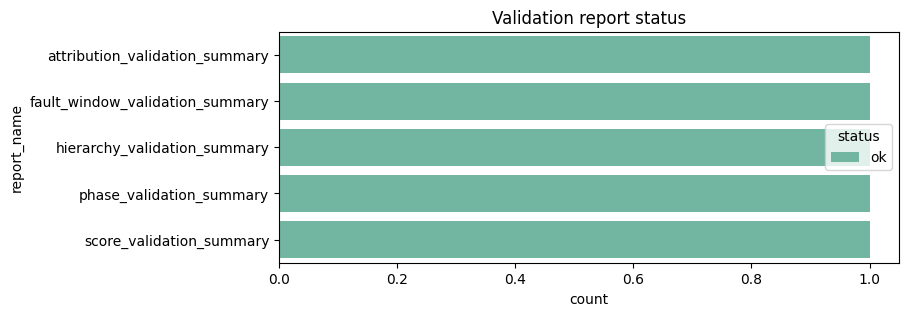

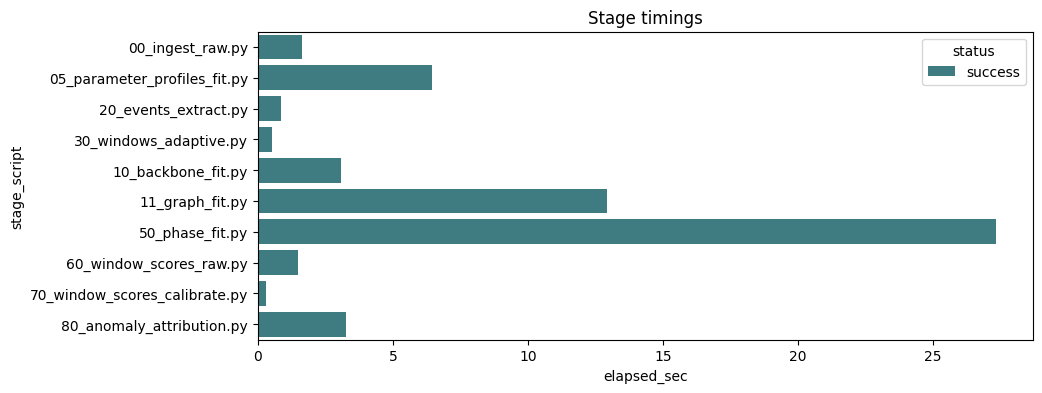

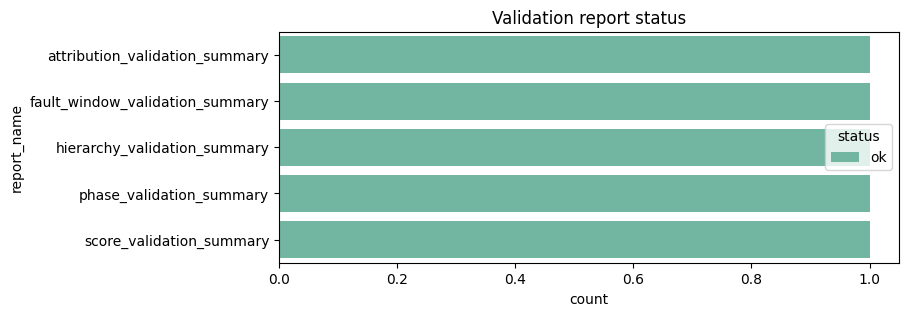

In [5]:
stage_fig = plot_stage_timings(bundle)
validation_fig = plot_validation_status(bundle)
stage_fig
validation_fig


In [6]:
ARTIFACT_PREVIEW_LIMIT = 200

hierarchy_df = load_artifact_table(bundle, "hierarchy_sensor_map", limit=ARTIFACT_PREVIEW_LIMIT)
phase_df = load_artifact_table(bundle, "phase_windows", limit=ARTIFACT_PREVIEW_LIMIT) if "phase_windows" in bundle.artifact_inventory else pd.DataFrame()
scores_df = load_artifact_table(bundle, "window_scores_calibrated", limit=ARTIFACT_PREVIEW_LIMIT) if "window_scores_calibrated" in bundle.artifact_inventory else pd.DataFrame()
anomaly_df = load_artifact_table(bundle, "anomaly_window_attribution", limit=ARTIFACT_PREVIEW_LIMIT) if "anomaly_window_attribution" in bundle.artifact_inventory else pd.DataFrame()
fused_graph_df = load_artifact_table(bundle, "fused_graph", limit=ARTIFACT_PREVIEW_LIMIT) if "fused_graph" in bundle.artifact_inventory else pd.DataFrame()
explorer_dataset = build_sensor_explorer_dataset(bundle)
explorer_options = build_sensor_explorer_filter_options(explorer_dataset["telemetry"])

display(Markdown("### Hierarchy preview"))
display(hierarchy_df.head(20))

display(Markdown("### Phase preview"))
display(phase_df.head(20))

display(Markdown("### Score preview"))
display(scores_df.head(20))

display(Markdown("### Anomaly preview"))
display(anomaly_df.head(20))

display(Markdown("### Fused graph preview"))
display(fused_graph_df.head(20))


### Hierarchy preview

,parameter_name,system_id,subsystem_id,module_id,hierarchy_source,hierarchy_profile_id
0,contactor_state,SYS_0001,SUBSYS_0001,MOD_0001,v2_fused_graph_mutual_topk_levels,HIER_V2
1,fuel_flow_rate,SYS_0001,SUBSYS_0001,MOD_0001,v2_fused_graph_mutual_topk_levels,HIER_V2
2,fuel_used_total,SYS_0001,SUBSYS_0001,MOD_0001,v2_fused_graph_mutual_topk_levels,HIER_V2
3,motor_speed,SYS_0001,SUBSYS_0001,MOD_0001,v2_fused_graph_mutual_topk_levels,HIER_V2
4,supply_voltage,SYS_0001,SUBSYS_0001,MOD_0001,v2_fused_graph_mutual_topk_levels,HIER_V2


### Phase preview

,win_id,t_start,t_end,duration_ms,event_count,phase_id_detected,phase_state_detected,phase_confidence_detected,distance_to_centroid_detected,drift_magnitude,breadth,backbone_reconstruction_error,backbone_residual_by_parameter,x_c,s_w,feature_names,selected_sensors_c,selected_event_types,selected_categorical_state_pairs,selected_window_cooccurrence_pairs,backbone_all_sensors,tail_id,flight_id,date_utc
0,1,2025-01-01 05:00:00,2025-01-01 05:00:03,3000,20,0,stable,1.0,0.000000,1.772181,1.0,0.427791,"[(contactor_state, 0.24212827988338192), (fuel...","[1.0, 1.0, 1.0, 0.0, 0.375]","[1.0, 1.0, 1.0, 0.0, 0.375, 0.5, 0.0, 0.35, 0....","[parameter_name::contactor_state, parameter_na...","[contactor_state, fuel_flow_rate, supply_volta...","[slope_pos, slope_neg, transition, state_enter]",[],[],"[contactor_state, fuel_flow_rate, fuel_used_to...",T_SIM,F_SIM,2025-01-01
1,2,2025-01-01 05:00:03,2025-01-01 05:00:06,3000,20,0,transition_region,0.0,1.966119,1.841365,1.0,0.341478,"[(contactor_state, -0.004373177842565598), (fu...","[0.0, 0.0, 0.0, 0.5, 0.0]","[0.0, 0.0, 0.0, 0.5, 0.0, 0.8, 0.2, 0.5, 0.0, ...","[parameter_name::contactor_state, parameter_na...","[contactor_state, fuel_flow_rate, supply_volta...","[slope_pos, slope_neg, transition, state_enter]",[],[],"[contactor_state, fuel_flow_rate, fuel_used_to...",T_SIM,F_SIM,2025-01-01
2,3,2025-01-01 05:00:06,2025-01-01 05:00:07,1000,11,1,stable,1.0,0.000000,0.312500,1.0,0.389022,"[(contactor_state, 0.02186588921282799), (fuel...","[0.0, 0.0, 0.0, 0.5, -0.3125]","[0.0, 0.0, 0.0, 0.5, -0.3125, 0.18181818181818...","[parameter_name::contactor_state, parameter_na...","[contactor_state, fuel_flow_rate, supply_volta...","[slope_pos, slope_neg, transition, state_enter]",[],[],"[contactor_state, fuel_flow_rate, fuel_used_to...",T_SIM,F_SIM,2025-01-01


### Score preview

,win_id,phase_state_detected,phase_id_detected,phase_confidence_detected,distance_to_centroid_detected,drift_magnitude,breadth,global_score,p_value,severity,dominant_subsystem_id,dominant_score_component,subsystem_scores,score_component_scores,warm,emit_ready,min_warm,tail_id,flight_id,date_utc
0,2,transition_region,0,0.0,1.966119,1.841365,1.0,983059.637052,0.5,high,SUBSYS_0001,structure,"[(SUBSYS_0001, 1.0)]","[(structure, 1966119.274103176), (reconstructi...",True,True,1,T_SIM,F_SIM,2025-01-01
1,1,stable,0,1.0,0.000000,1.772181,1.0,0.000000,1.0,normal,SUBSYS_0001,structure,"[(SUBSYS_0001, 1.0)]","[(structure, 0.0), (reconstruction, 0.0)]",True,True,1,T_SIM,F_SIM,2025-01-01
2,3,stable,1,1.0,0.000000,0.312500,1.0,0.000000,1.0,normal,SUBSYS_0001,structure,"[(SUBSYS_0001, 1.0)]","[(structure, 0.0), (reconstruction, 0.0)]",True,True,1,T_SIM,F_SIM,2025-01-01


### Anomaly preview

,win_id,timestamp_utc,phase_state_detected,phase_id_detected,phase_confidence_detected,distance_to_centroid_detected,drift_magnitude,breadth,global_score,p_value,severity,dominant_subsystem_id,dominant_score_component,panel_context,subsystems,attribution_context,artifact_versions,tail_id,flight_id,date_utc
0,1,2025-01-01 05:00:03,stable,0,1.0,0.000000,1.772181,1.0,0.000000,1.0,normal,SUBSYS_0001,structure,None,"[{'id': 'SUBSYS_0001', 'name': 'SUBSYS_0001', ...","{'score_component_scores': [('structure', 0.0)...","{'backbone': 1, 'graph': 1, 'phase': 1, 'scori...",T_SIM,F_SIM,2025-01-01
1,3,2025-01-01 05:00:07,stable,1,1.0,0.000000,0.312500,1.0,0.000000,1.0,normal,SUBSYS_0001,structure,None,"[{'id': 'SUBSYS_0001', 'name': 'SUBSYS_0001', ...","{'score_component_scores': [('structure', 0.0)...","{'backbone': 1, 'graph': 1, 'phase': 1, 'scori...",T_SIM,F_SIM,2025-01-01
2,2,2025-01-01 05:00:06,transition_region,0,0.0,1.966119,1.841365,1.0,983059.637052,0.5,high,SUBSYS_0001,structure,None,"[{'id': 'SUBSYS_0001', 'name': 'SUBSYS_0001', ...","{'score_component_scores': [('structure', 1966...","{'backbone': 1, 'graph': 1, 'phase': 1, 'scori...",T_SIM,F_SIM,2025-01-01


### Fused graph preview

,parameter_name_u,parameter_name_v,precision_weight,event_weight,lag_weight,fused_weight,edge_family
0,contactor_state,fuel_flow_rate,0.180979,0.0,0.201754,0.382733,fused
1,contactor_state,fuel_used_total,0.084910,0.0,0.252632,0.337542,fused
2,contactor_state,motor_speed,0.089317,0.0,0.303509,0.392826,fused
3,contactor_state,supply_voltage,0.180979,0.0,0.201754,0.382733,fused
4,fuel_flow_rate,fuel_used_total,0.084910,0.0,0.252632,0.337542,fused
5,fuel_flow_rate,motor_speed,0.089317,0.0,0.303509,0.392826,fused
6,fuel_flow_rate,supply_voltage,0.180979,0.0,0.201754,0.382733,fused
7,fuel_used_total,motor_speed,0.000000,0.0,0.320370,0.320370,fused
8,fuel_used_total,supply_voltage,0.000000,0.0,0.252632,0.252632,fused
9,motor_speed,supply_voltage,0.000000,0.0,0.303509,0.303509,fused


In [7]:
display(Markdown("### Sensor explorer filter options"))
display(pd.DataFrame({key: pd.Series(value) for key, value in explorer_options.items()}))

# Dash-ready explorer state. Adjust and rerun the figure cell below.
EXPLORER_STATE = SensorExplorerState(
    system_id=None,
    subsystem_id=None,
    module_id=None,
    parameter_names=(),
    scale_mode="normalized",  # normalized | raw | subplots | dual_axis
    show_events=True,
    show_anomaly_markers=True,
    show_anomaly_windows=True,
    show_phase_shading=True,
    time_start=None,
    time_end=None,
)
EXPLORER_STATE


### Sensor explorer filter options

,system_ids,subsystem_ids,module_ids,parameter_names
0,SYS_FUEL,SUB_FUEL,MOD_SOURCE,contactor_state
1,SYS_POWER,SUB_LOAD,MOD_SWITCH,fuel_flow_rate
2,NaN,SUB_POWER,MOD_TANK,fuel_used_total
3,NaN,NaN,MOD_TARGET,motor_speed
4,NaN,NaN,NaN,supply_voltage


SensorExplorerState(system_id=None, subsystem_id=None, module_id=None, parameter_names=(), scale_mode='normalized', show_events=True, show_anomaly_markers=True, show_anomaly_windows=True, show_phase_shading=True, time_start=None, time_end=None)

In [8]:
sensor_explorer_figure = build_sensor_explorer_figure(explorer_dataset, EXPLORER_STATE)
sensor_explorer_figure


/home/jrs/code/S3NTINEL/sentinel/libs/plotting/simulation_artifacts.py:287: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hierarchy_df, x="system_id", ax=axes[0], palette="Blues")
/home/jrs/code/S3NTINEL/sentinel/libs/plotting/simulation_artifacts.py:290: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hierarchy_df, x="subsystem_id", ax=axes[1], palette="Greens")
/home/jrs/code/S3NTINEL/sentinel/libs/plotting/simulation_artifacts.py:294: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_counts, x="size", y="module_id", ax

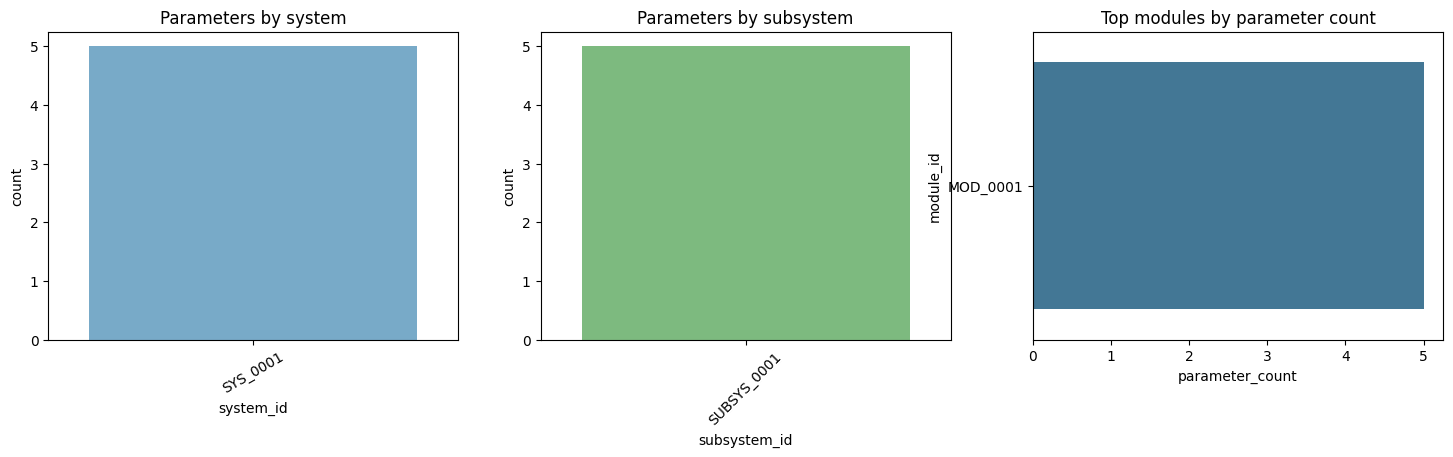

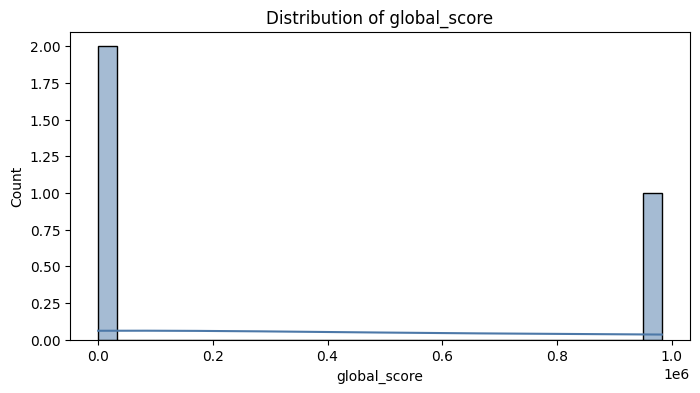

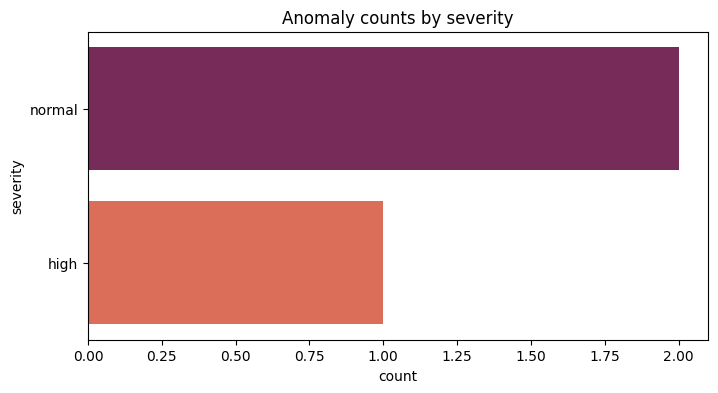

In [9]:
plot_hierarchy_overview(hierarchy_df)
plot_phase_overview(phase_df)
plot_score_distribution(scores_df)
plot_anomaly_summary(anomaly_df)
plot_graph_edge_weights(fused_graph_df)


In [10]:
log_records_df = extract_log_records(bundle.log_text)
display(Markdown("### Parsed log records"))
display(log_records_df.tail(30))

if not log_records_df.empty:
    error_records = log_records_df[log_records_df["level"].isin(["ERROR", "WARN"])]
    display(Markdown("### Warning and error records"))
    display(error_records.tail(30))


### Parsed log records

,timestamp,level,logger,message
25,2026-03-14 12:46:18,INFO,__main__,pipeline=backbone_fit format=parquet write_mod...
26,2026-03-14 12:46:18,INFO,__main__,wall_time_ms=3075.641 label=__main__.run
27,2026-03-14 12:46:18,INFO,s3ntinel.run_sim_pipeline,stage_end script=10_backbone_fit.py elapsed_ms...
28,2026-03-14 12:46:18,INFO,s3ntinel.run_sim_pipeline,stage_start script=11_graph_fit.py
29,2026-03-14 12:46:18,INFO,__main__,mlflow_unavailable stage=11_graph_fit
30,2026-03-14 12:46:31,INFO,__main__,pipeline=graph_fit format=parquet write_mode=o...
31,2026-03-14 12:46:31,INFO,__main__,wall_time_ms=12915.046 label=__main__.run
32,2026-03-14 12:46:31,INFO,s3ntinel.run_sim_pipeline,stage_end script=11_graph_fit.py elapsed_ms=12...
33,2026-03-14 12:46:31,INFO,s3ntinel.run_sim_pipeline,stage_start script=50_phase_fit.py
34,2026-03-14 12:46:31,INFO,__main__,mlflow_unavailable stage=50_phase_fit


### Warning and error records

,timestamp,level,logger,message


In [11]:
display(Markdown("### Recent raw log excerpt"))
if bundle.log_text:
    print("\n".join(bundle.log_text.splitlines()[-40:]))
else:
    print("Log file missing.")


### Recent raw log excerpt

2026-03-14T12:46:14 | INFO | __main__ | pipeline=events_extract format=parquet write_mode=overwrite event_threshold=20 delta_threshold=0.0 slope_source=ema ema_alpha=0.2 input=data/simulation_runs/20260314T164559Z_power_chain/delta/raw_telemetry output=data/simulation_runs/20260314T164559Z_power_chain/delta/events
2026-03-14T12:46:14 | INFO | __main__ | wall_time_ms=857.025 label=__main__.run
2026-03-14T12:46:14 | INFO | s3ntinel.run_sim_pipeline | stage_end script=20_events_extract.py elapsed_ms=859.851
2026-03-14T12:46:14 | INFO | s3ntinel.run_sim_pipeline | stage_start script=30_windows_adaptive.py
2026-03-14T12:46:14 | INFO | __main__ | mlflow_unavailable stage=30_windows_adaptive
2026-03-14T12:46:15 | INFO | __main__ | pipeline=windows_adaptive format=parquet write_mode=overwrite strategy=bucketed max_ms=10000 event_threshold=20 inactivity_timeout_ms=0 input=data/simulation_runs/20260314T164559Z_power_chain/delta/events output=data/simulation_runs/20260314T164559Z_power_chain/delt